In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import joblib

OUTPUT_DIR = r"C:\\Users\\mribl\\Documents\\GitHub\\College\\Sem 7\\Advance Predictive Analysis\\Lab\\DA 2\\output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42

Data shape: (569, 30)
Class counts: {0: 357, 1: 212}


C:\Users\mribl\AppData\Local\Temp\ipykernel_11520\1599599405.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Label", y="Count", data=freq_table, palette=["#2b5c8f", "#d95f02"], ax=ax)


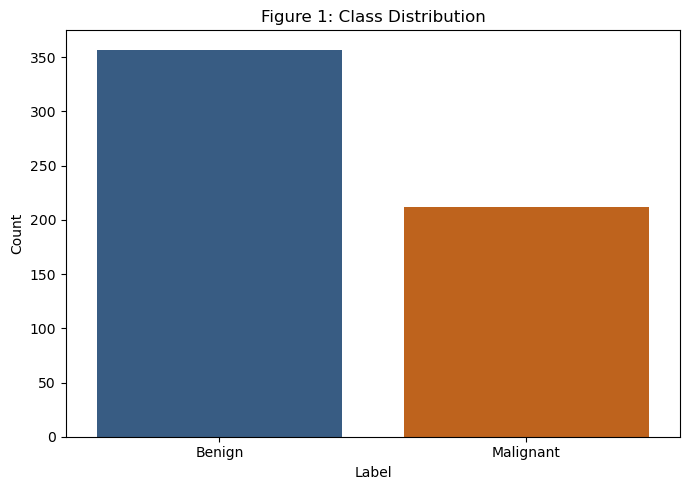

In [2]:
raw = load_breast_cancer(as_frame=True)
X = raw.data.copy()
y = (raw.target == 0).astype(int)
y.name = "malignant"

print("Data shape:", X.shape)
print("Class counts:", y.value_counts().to_dict())

freq_table = pd.DataFrame({
    "Label": ["Benign", "Malignant"],
    "Count": [sum(y == 0), sum(y == 1)]
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x="Label", y="Count", data=freq_table, palette=["#2b5c8f", "#d95f02"], ax=ax)
ax.set_title("Figure 1: Class Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure1_class_distribution.png"), dpi=300)
plt.show()

Missing values: 0
Duplicates: 0


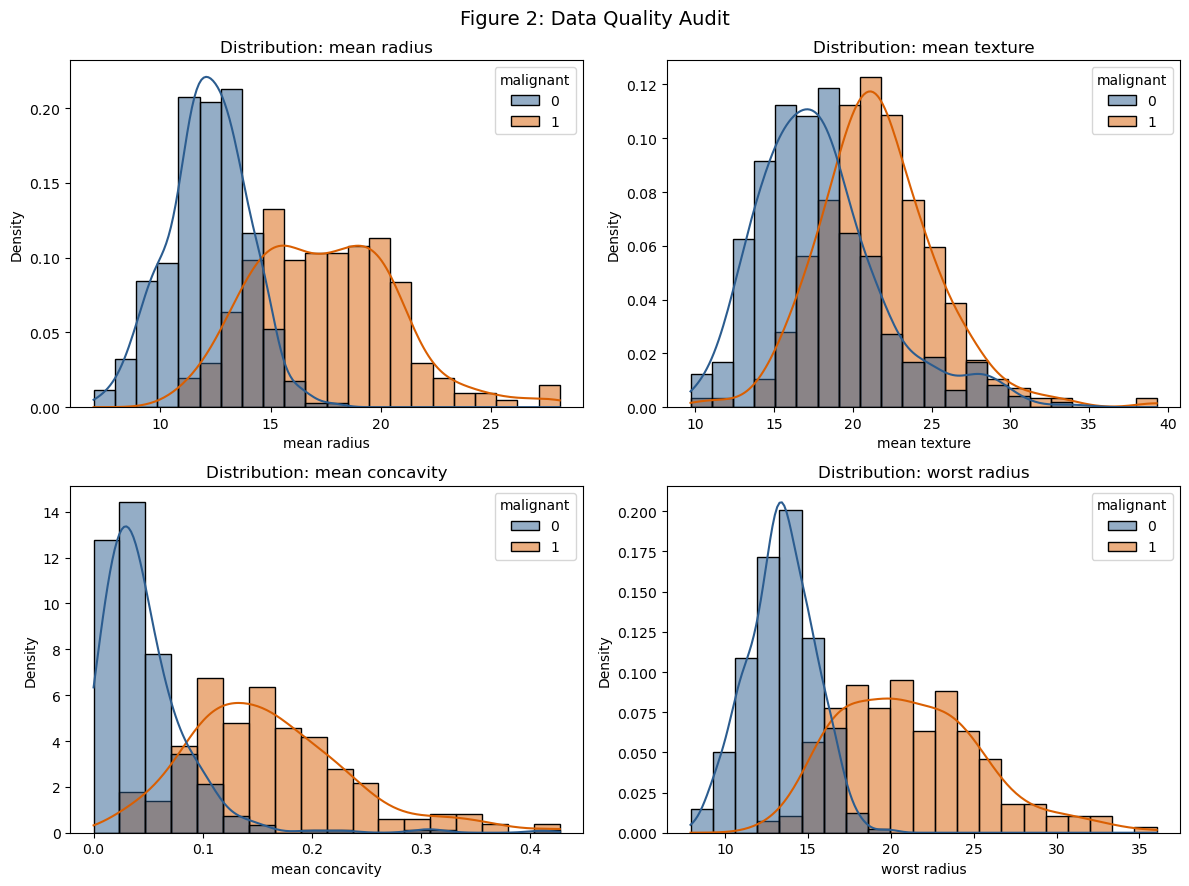

In [3]:
print("Missing values:", X.isna().sum().sum())
print("Duplicates:", X.duplicated().sum())

selected_features = ["mean radius", "mean texture", "mean concavity", "worst radius"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, feat in enumerate(selected_features):
    sns.histplot(data=X.assign(malignant=y), x=feat, hue="malignant", kde=True,
                 palette=["#2b5c8f", "#d95f02"], stat="density", common_norm=False, ax=axes[i])
    axes[i].set_title(f"Distribution: {feat}")
plt.suptitle("Figure 2: Data Quality Audit", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure2_data_quality_audit.png"), dpi=300)
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tree_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


Best ccp_alpha: 0.0


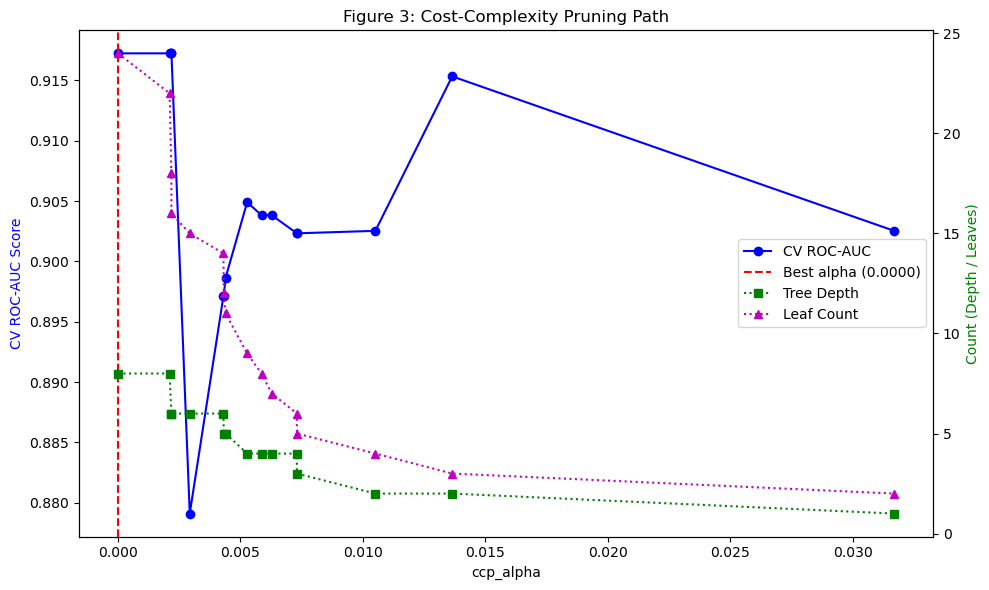

In [5]:
base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas[:-1])

prune_scores, tree_depths, tree_leaves = [], [], []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=RANDOM_STATE)
    scores = cross_validate(dt, X_train, y_train, cv=cv, scoring="roc_auc")
    dt.fit(X_train, y_train)
    prune_scores.append(scores["test_score"].mean())
    tree_depths.append(dt.get_depth())
    tree_leaves.append(dt.get_n_leaves())

best_alpha = ccp_alphas[np.argmax(prune_scores)]
print("Best ccp_alpha:", best_alpha)

prune_search = GridSearchCV(
    tree_pipe,
    param_grid={"model__ccp_alpha": ccp_alphas, "model__class_weight": [None, "balanced"]},
    scoring="roc_auc", cv=cv, n_jobs=-1
)
prune_search.fit(X_train, y_train)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(ccp_alphas, prune_scores, marker='o', color='b', label='CV ROC-AUC')
ax1.set_xlabel("ccp_alpha")
ax1.set_ylabel("CV ROC-AUC Score", color='b')
ax1.axvline(best_alpha, color='r', linestyle='--', label=f'Best alpha ({best_alpha:.4f})')

ax2 = ax1.twinx()
ax2.plot(ccp_alphas, tree_depths, marker='s', color='g', linestyle=':', label='Tree Depth')
ax2.plot(ccp_alphas, tree_leaves, marker='^', color='m', linestyle=':', label='Leaf Count')
ax2.set_ylabel("Count (Depth / Leaves)", color='g')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title("Figure 3: Cost-Complexity Pruning Path")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure3_pruning_path.png"), dpi=300)
plt.show()

Selected threshold: 0.85
Test Accuracy: 0.9298
Test ROC-AUC: 0.9431


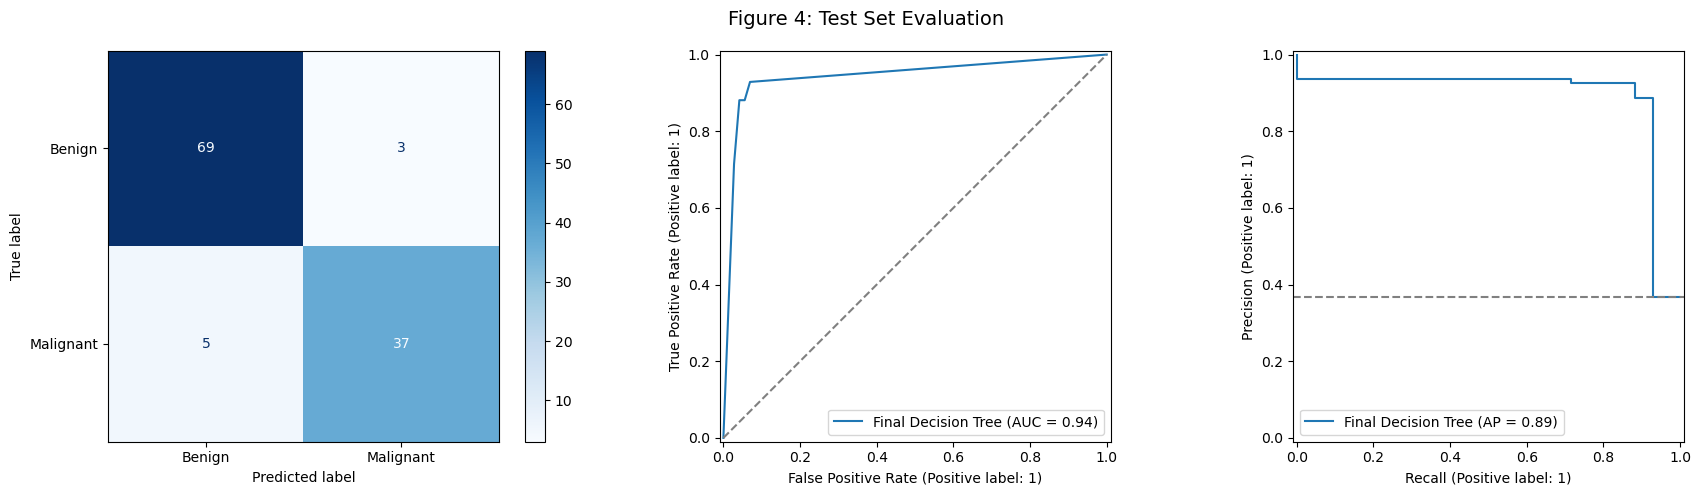

In [6]:
selected_model = prune_search.best_estimator_
oof_prob = cross_val_predict(selected_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

threshold_rows = []
for th in np.linspace(0.05, 0.95, 181):
    pred = (oof_prob >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    threshold_rows.append((th, sens, spec))

threshold_df = pd.DataFrame(threshold_rows, columns=["threshold", "sensitivity", "specificity"])
selected_threshold = threshold_df[threshold_df["sensitivity"] >= 0.90].sort_values("specificity", ascending=False).iloc[0]["threshold"]
print("Selected threshold:", round(selected_threshold, 4))

final_model = selected_model.fit(X_train, y_train)
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= selected_threshold).astype(int)

print("Test Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, test_prob), 4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["Benign", "Malignant"], cmap="Blues", values_format="d", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, test_prob, name="Final Decision Tree", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="gray")
PrecisionRecallDisplay.from_predictions(y_test, test_prob, name="Final Decision Tree", ax=axes[2])
axes[2].axhline(y_test.mean(), linestyle="--", color="gray")
plt.suptitle("Figure 4: Test Set Evaluation", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure4_test_evaluation.png"), dpi=300)
plt.show()

Tree depth: 3
Leaf count: 5


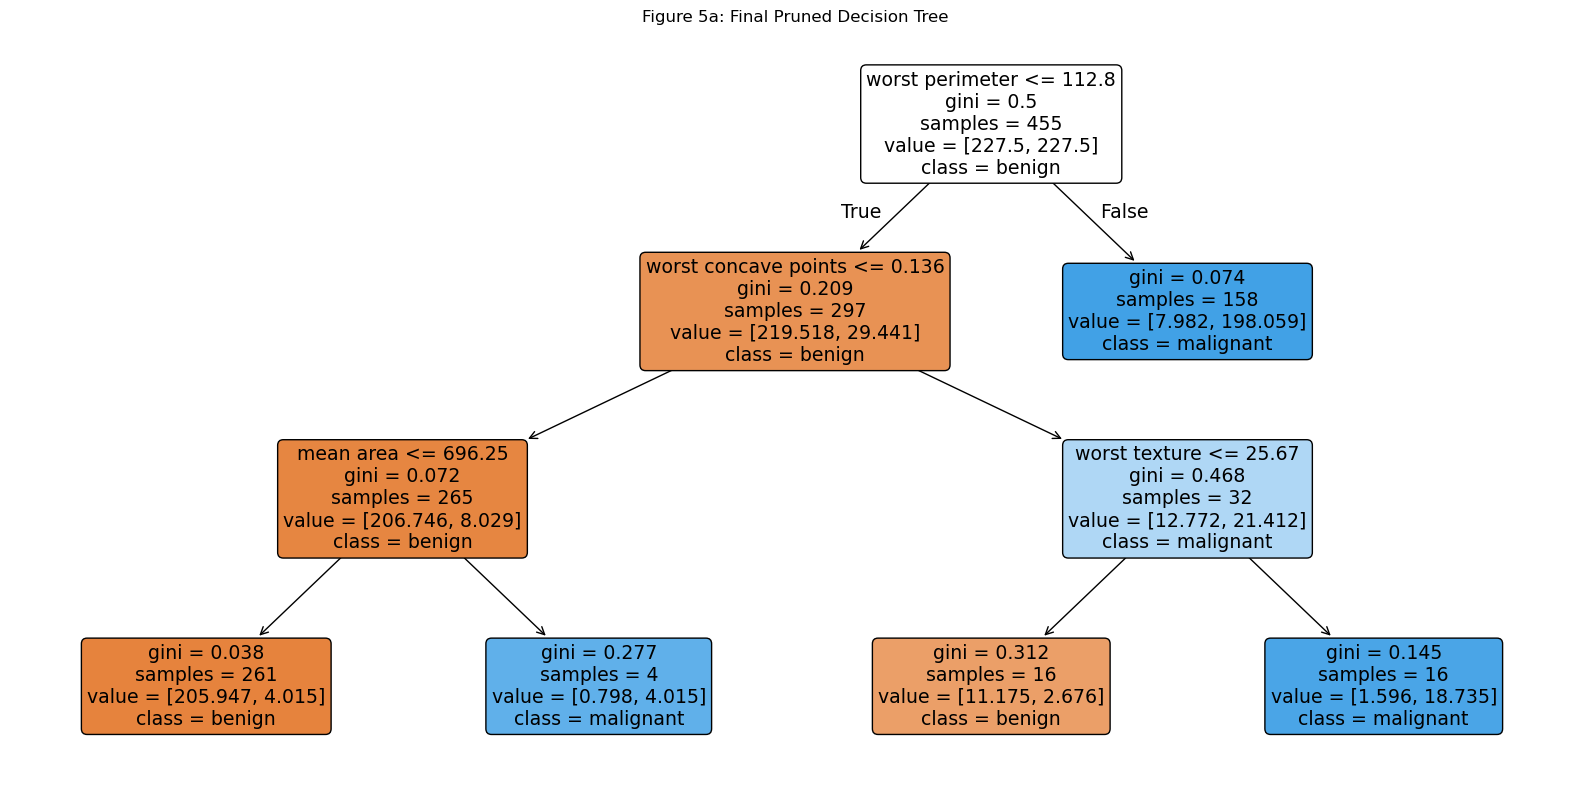

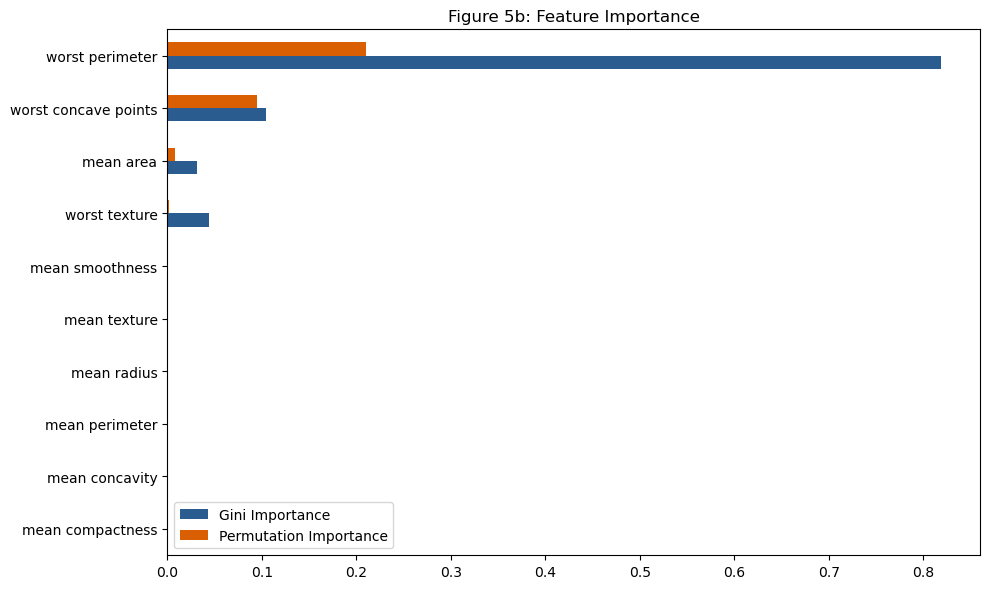

In [7]:
fitted_tree = final_model.named_steps["model"]
print("Tree depth:", fitted_tree.get_depth())
print("Leaf count:", fitted_tree.get_n_leaves())

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(fitted_tree, feature_names=X_train.columns, class_names=["benign", "malignant"], filled=True, rounded=True, ax=ax)
plt.title("Figure 5a: Final Pruned Decision Tree")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure5_decision_tree.png"), dpi=300)
plt.show()

gini_imp = pd.Series(fitted_tree.feature_importances_, index=X_train.columns)
perm_res = permutation_importance(final_model, X_test, y_test, scoring="roc_auc", n_repeats=30, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm_res.importances_mean, index=X_test.columns)
top_features = gini_imp.nlargest(10).index.union(perm_imp.nlargest(10).index)
comp_df = pd.DataFrame({"Gini Importance": gini_imp[top_features], "Permutation Importance": perm_imp[top_features]}).fillna(0).sort_values("Permutation Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
comp_df.plot(kind="barh", ax=ax, color=["#2b5c8f", "#d95f02"])
plt.title("Figure 5b: Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure5_feature_importance.png"), dpi=300)
plt.show()

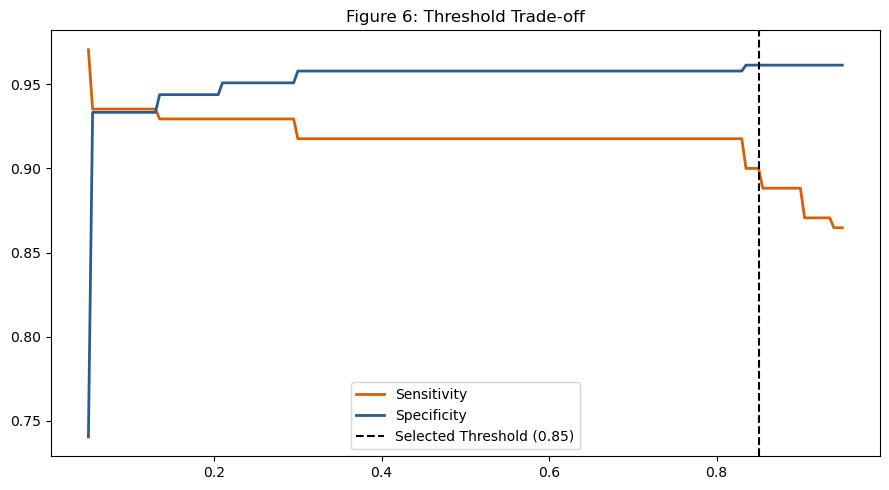

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["sensitivity"], label="Sensitivity", color="#d95f02", lw=2)
ax.plot(threshold_df["threshold"], threshold_df["specificity"], label="Specificity", color="#2b5c8f", lw=2)
ax.axvline(selected_threshold, color="black", linestyle="--", label=f"Selected Threshold ({selected_threshold:.2f})")
ax.set_title("Figure 6: Threshold Trade-off")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure6_threshold_sensitivity_stability.png"), dpi=300)
plt.show()

In [9]:
artifact = {
    "model": final_model,
    "threshold": float(selected_threshold),
    "positive_class": "malignant",
    "feature_names": list(X_train.columns),
    "random_state": RANDOM_STATE
}
joblib.dump(artifact, os.path.join(OUTPUT_DIR, "lab02_decision_tree_artifact.joblib"))
print("Artifact saved successfully.")

Artifact saved successfully.
